In [9]:
# Run this first to install everything needed
!pip install torch torchvision matplotlib numpy pillow -q

print("✓ All packages installed!")

✓ All packages installed!


In [10]:
# Import all the tools we need
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Check if we have GPU (faster training)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


In [11]:
# Download Cats vs Dogs dataset (happens automatically)
# This will download ~800MB of cat and dog images

from torchvision.datasets import OxfordIIITPet

# Download the Oxford Pets dataset (has cats and dogs with labels)
dataset = OxfordIIITPet(
    root="./data",
    download=True,
    transform=None  # We'll add transforms later
)

print(f"✓ Dataset downloaded!")
print(f"✓ Total images: {len(dataset)}")

# Let's see what classes we have
print(f"\nClasses available:")
# Class 1 = Cat, Class 2 = Dog in this dataset
print("  1 = Cat")
print("  2 = Dog")

✓ Dataset downloaded!
✓ Total images: 3680

Classes available:
  1 = Cat
  2 = Dog


In [12]:
# Define how to transform/resize images
# Training: Add random changes to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),           # Make all images same size
    transforms.RandomHorizontalFlip(),       # Randomly flip left-right
    transforms.RandomRotation(10),           # Randomly rotate
    transforms.ColorJitter(brightness=0.2),  # Randomly change brightness
    transforms.ToTensor(),                   # Convert to PyTorch tensor
    transforms.Normalize(                    # Normalize colors
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation: Only resize and normalize (no random changes)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create a custom dataset class that maps labels to Cat/Dog
class CatDogDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]

        # In OxfordIIITPet: label 1 = Cat, label 2 = Dog
        # We convert to: 0 = Cat, 1 = Dog
        new_label = 0 if label == 1 else 1

        if self.transform:
            image = self.transform(image)

        return image, new_label

# Load dataset with transforms
full_dataset = OxfordIIITPet(root="./data", download=True)
full_dataset = CatDogDataset(full_dataset, train_transform)

# Split into training (80%) and validation (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply different transforms to validation set
val_dataset.dataset = CatDogDataset(OxfordIIITPet(root="./data"), val_transform)

# Create data loaders (handle batching)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

CLASS_NAMES = ['Cat', 'Dog']
NUM_CLASSES = 2

print(f"✓ Training images: {len(train_dataset)}")
print(f"✓ Validation images: {len(val_dataset)}")
print(f"✓ Classes: {CLASS_NAMES}")

✓ Training images: 2944
✓ Validation images: 736
✓ Classes: ['Cat', 'Dog']


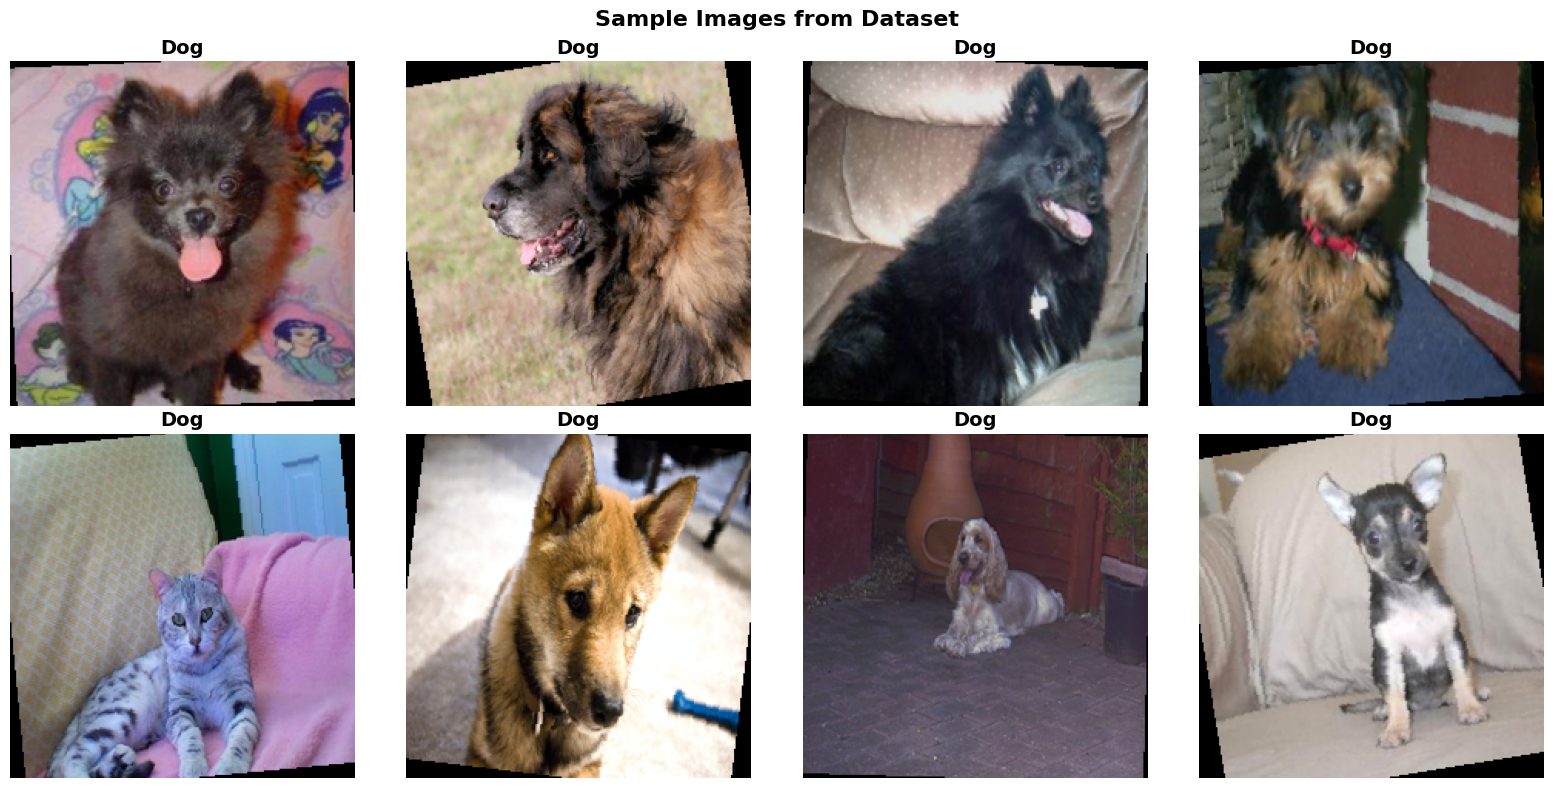

In [13]:
# Let's see some images from our dataset
def show_samples(dataloader, class_names, num_samples=8):
    """Display sample images with their labels."""

    # Get one batch of images
    images, labels = next(iter(dataloader))

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(num_samples):
        # Un-normalize the image for display
        img = images[i].numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        label_name = class_names[labels[i]]
        axes[i].set_title(f"{label_name}", fontsize=14, fontweight='bold')
        axes[i].axis('off')

    plt.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show samples
show_samples(train_loader, CLASS_NAMES)

In [14]:
# We'll use a pre-trained model (Transfer Learning)
# This is much faster and more accurate than training from scratch

def create_model(num_classes=2):
    """
    Create a model using pre-trained MobileNetV2.
    We replace the final layer to match our 2 classes (Cat/Dog).
    """

    # Load pre-trained MobileNetV2
    model = models.mobilenet_v2(pretrained=True)

    # Freeze all the pre-trained layers (don't change them)
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final classification layer
    # Original: outputs 1000 classes (ImageNet)
    # New: outputs 2 classes (Cat, Dog)
    model.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(model.last_channel, num_classes)
    )

    return model

# Create the model
model = create_model(NUM_CLASSES)
model = model.to(device)  # Move to GPU if available

print("✓ Model created!")
print(f"✓ Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"✓ Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✓ Model created!
✓ Total parameters: 2,226,434
✓ Trainable parameters: 2,562


In [15]:
import torch.optim as optim
import torch.nn as nn

# Loss function: measures how wrong the predictions are
criterion = nn.CrossEntropyLoss()

# Optimizer: updates the model to make better predictions
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler: reduces learning rate if we stop improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

NUM_EPOCHS = 10  # How many times to go through all the data

print("✓ Training setup complete!")
print(f"  - Loss function: CrossEntropyLoss")
print(f"  - Optimizer: Adam (learning rate=0.001)")
print(f"  - Epochs: {NUM_EPOCHS}")

✓ Training setup complete!
  - Loss function: CrossEntropyLoss
  - Optimizer: Adam (learning rate=0.001)
  - Epochs: 10


In [16]:
# Training loop - this is where the model learns
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    """Train the model and track performance."""

    # Store results for plotting
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # ============ TRAINING PHASE ============
        model.train()  # Set model to training mode
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            # Move data to GPU/CPU
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass: make predictions
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass: learn from mistakes
            optimizer.zero_grad()  # Clear old gradients
            loss.backward()        # Calculate new gradients
            optimizer.step()       # Update model weights

            # Track statistics
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss = train_loss / len(train_loader)
        train_acc = 100 * train_correct / train_total

        # ============ VALIDATION PHASE ============
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # Don't calculate gradients (faster)
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * val_correct / val_total

        # Update learning rate based on validation loss
        scheduler.step(val_loss)

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')

        # Print progress
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    print(f"\n✓ Training complete! Best validation accuracy: {best_val_acc:.2f}%")
    return history

# Run training
print("=" * 70)
print("STARTING TRAINING...")
print("=" * 70)

history = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler, NUM_EPOCHS
)

STARTING TRAINING...
Epoch [1/10] Train Loss: 0.1074 | Train Acc: 97.28% | Val Loss: 0.0521 | Val Acc: 98.37%
Epoch [2/10] Train Loss: 0.0617 | Train Acc: 97.72% | Val Loss: 0.0631 | Val Acc: 98.37%
Epoch [3/10] Train Loss: 0.0507 | Train Acc: 98.10% | Val Loss: 0.0325 | Val Acc: 98.37%
Epoch [4/10] Train Loss: 0.0420 | Train Acc: 98.47% | Val Loss: 0.0322 | Val Acc: 98.37%
Epoch [5/10] Train Loss: 0.0417 | Train Acc: 98.57% | Val Loss: 0.0320 | Val Acc: 98.78%
Epoch [6/10] Train Loss: 0.0416 | Train Acc: 98.23% | Val Loss: 0.0284 | Val Acc: 98.64%
Epoch [7/10] Train Loss: 0.0366 | Train Acc: 98.78% | Val Loss: 0.0296 | Val Acc: 98.64%
Epoch [8/10] Train Loss: 0.0360 | Train Acc: 98.78% | Val Loss: 0.0283 | Val Acc: 98.78%
Epoch [9/10] Train Loss: 0.0302 | Train Acc: 98.68% | Val Loss: 0.0505 | Val Acc: 98.37%
Epoch [10/10] Train Loss: 0.0336 | Train Acc: 98.54% | Val Loss: 0.0283 | Val Acc: 98.64%

✓ Training complete! Best validation accuracy: 98.78%


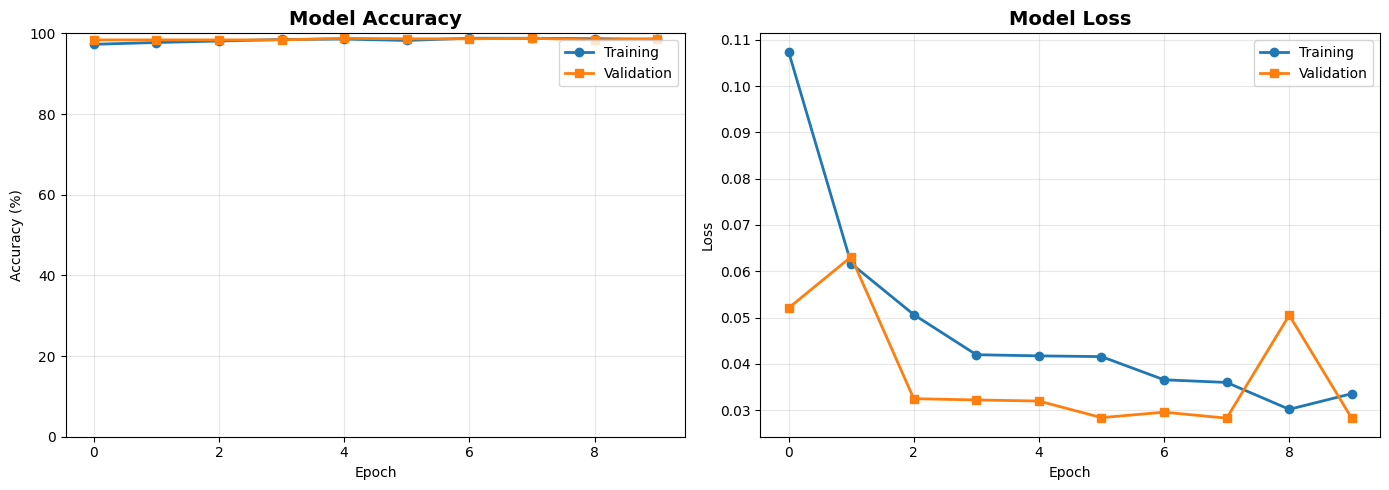

In [17]:
# Visualize how the model improved over time
def plot_history(history):
    """Plot training and validation metrics."""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(history['train_acc'], label='Training', marker='o', linewidth=2)
    axes[0].plot(history['val_acc'], label='Validation', marker='s', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 100])

    # Loss plot
    axes[1].plot(history['train_loss'], label='Training', marker='o', linewidth=2)
    axes[1].plot(history['val_loss'], label='Validation', marker='s', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot the results
plot_history(history)

In [18]:
# See how well the model performs on unseen data
def evaluate_model(model, val_loader, class_names):
    """Evaluate model and show detailed results."""

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Calculate accuracy
    accuracy = 100 * sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    print(f"{'='*50}")
    print(f"VALIDATION ACCURACY: {accuracy:.2f}%")
    print(f"{'='*50}")

    # Classification report
    print("\nDetailed Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return all_labels, all_preds

# Run evaluation
y_true, y_pred = evaluate_model(model, val_loader, CLASS_NAMES)

VALIDATION ACCURACY: 98.64%

Detailed Report:
              precision    recall  f1-score   support

         Cat       0.81      0.65      0.72        20
         Dog       0.99      1.00      0.99       716

    accuracy                           0.99       736
   macro avg       0.90      0.82      0.86       736
weighted avg       0.99      0.99      0.99       736



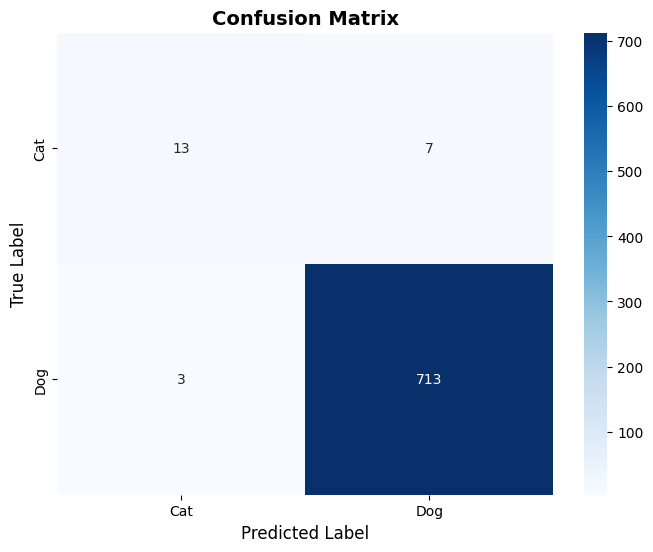

Per-class accuracy:
  Cat: 65.0%
  Dog: 99.6%


In [19]:
# Visualize where the model makes mistakes
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot a confusion matrix."""

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()

    print("Per-class accuracy:")
    for i, name in enumerate(class_names):
        class_acc = 100 * cm[i, i] / cm[i].sum()
        print(f"  {name}: {class_acc:.1f}%")

# Plot confusion matrix
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

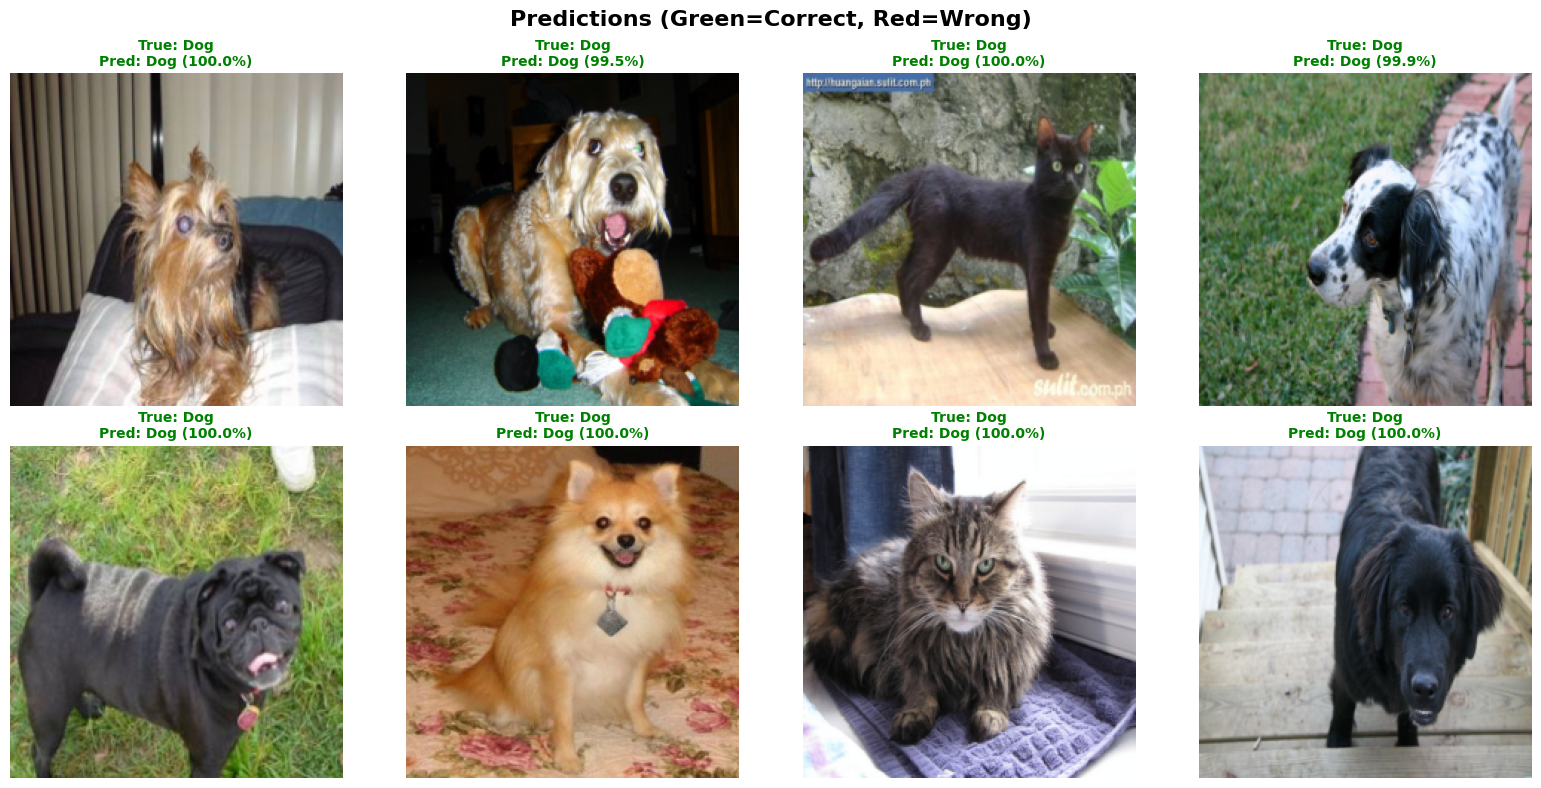

In [20]:
# See actual predictions on images
def show_predictions(model, dataloader, class_names, num_samples=8):
    """Show model predictions on sample images."""

    model.eval()
    images, labels = next(iter(dataloader))

    with torch.no_grad():
        images_gpu = images.to(device)
        outputs = model(images_gpu)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(num_samples):
        # Un-normalize image
        img = images[i].numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)

        true_label = class_names[labels[i]]
        pred_label = class_names[predicted[i]]
        confidence = probs[i][predicted[i]].item() * 100

        # Green if correct, red if wrong
        is_correct = labels[i] == predicted[i]
        color = 'green' if is_correct else 'red'

        axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                         fontsize=10, color=color, fontweight='bold')
        axes[i].axis('off')

    plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show predictions
show_predictions(model, val_loader, CLASS_NAMES)

In [21]:
# Save model for later use
def save_model(model, class_names, path='animal_face_model.pth'):
    """Save the model and class names."""

    # Save model weights
    torch.save({
        'model_state_dict': model.state_dict(),
        'class_names': class_names,
    }, path)

    print(f"✓ Model saved to: {path}")
    print(f"  File size: {os.path.getsize(path) / 1024 / 1024:.2f} MB")

import os
save_model(model, CLASS_NAMES)

✓ Model saved to: animal_face_model.pth
  File size: 8.73 MB


In [22]:
# Function to predict on any image
def predict_image(image_path, model, class_names, transform):
    """Predict animal in a single image."""

    from PIL import Image

    # Load and transform image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)

    # Get results
    pred_class = class_names[predicted.item()]
    pred_confidence = confidence.item() * 100

    # Display
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(f"Prediction: {pred_class}\nConfidence: {pred_confidence:.1f}%",
             fontsize=14, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()

    # Show all probabilities
    print("\nProbabilities:")
    for i, name in enumerate(class_names):
        prob = probs[0][i].item() * 100
        print(f"  {name}: {prob:.1f}%")

    return pred_class, pred_confidence

print("predict_image() function is ready!")
print("\nUsage example:")
print('  predict_image("path/to/your/image.jpg", model, CLASS_NAMES, val_transform)')

predict_image() function is ready!

Usage example:
  predict_image("path/to/your/image.jpg", model, CLASS_NAMES, val_transform)
